In [1]:
import numpy as np
import pandas as pd
import cupy as cp
import igpu, pickle
from matplotlib import pyplot as plt

In [2]:
def to_day(di):
    if di >= 2:
        return "day6"
    else:
        return "day" + str(di + 1)

In [3]:
with open("w.pkl", "rb") as f:
    w = pickle.load(f)
with open("h.pkl", "rb") as f:
    h = pickle.load(f)
x = []
for mi in range(6):
    mouse = "mouse" + str(mi + 1)
    xs = []
    for di in range(3):
        day = to_day(di)
        xs.append(pd.read_csv(mouse + "/" + mouse + "_" + day + ".csv", header=None).values)
    x.append(xs)

In [4]:
w_single = []
h_single = []
for mi in range(6):
    ws = []
    hs = []
    for di in range(3):
        t_h, k = h[mi][di].shape
        n, _, l = w[mi][di].shape
        win = l - 1
        win2 = 2 * l - 1
        wss = np.zeros((n, k, 2))
        hss = np.zeros((t_h, k))
        x_min = x[mi][di][x[mi][di] > 0].min()
        print("Processing mouse {}, {} ".format(mi + 1, to_day(di)), end="")
        for ki in range(k):
            u = cp.asnumpy(igpu.conv(cp.asarray(w[mi][di][:, ki:ki+1, :]), cp.asarray(h[mi][di][:, ki:ki+1]).T, x_min))
            # for calculation of corrcoef
            umu = u - u.mean(axis=1)[:, np.newaxis]
            umu2 = umu * umu
            # the most significant cell ID
            i = u.sum(axis=1).argmax()
            
            # matrix contains corrcoef
            tmp = np.zeros((n, win2))
            for j in range(n):
                if j == i:
                    tmp[i, win] = 1
                    continue
                den2i0 = umu2[i].sum()
                den2j0 = umu2[j].sum()
                if den2j0 == 0:
                    continue
                tmp[j, win] = (umu[i] * umu[j]).sum() / np.sqrt(den2i0 * den2j0)
                den2i = den2i0
                den2j = den2j0
                for p in range(1, l):
                    den2i -= umu2[i, -p]
                    den2j -= umu2[j, p - 1]
                    tmp[j, win - p] = (umu[i, p:] * umu[j, :-p]).sum() / np.sqrt(den2i * den2j)
                den2i = den2i0
                den2j = den2j0
                for p in range(1, l):
                    den2i -= umu2[i, -p]
                    den2j -= umu2[j, p - 1]
                    tmp[j, win + p] = (umu[i, :-p] * umu[j, p:]).sum() / np.sqrt(den2i * den2j)

            # Determine the positions of cell activities based on the significant cell
            index = tmp.argmax(axis=1)
            index_count = np.array([(index == i).sum() for i in range(win2)])
            scand = np.zeros(win)
            c = index_count[:win].sum()
            for s in range(win):
                c += index_count[s + win]
                scand[s] = c
                c -= index_count[s]
            # starting point of the sequential activity
            start = scand.argmax()

            # Determine W and calculate H inversely.
            # Use the average value for the final H.
            w_pos = tmp[:, start:start+l].argmax(axis=1)
            w_act = u.sum(axis=1) / u.sum()
            h_raw = u / w_act[:, np.newaxis]
            h_count = np.zeros(t_h)
            for i, (a, p) in enumerate(zip(w_act, w_pos)):
                hss[win-p:t_h-p, ki] += a * h_raw[i]
                h_count[win-p:t_h-p] += a
            h_count[h_count == 0] = 1
            hss[:, ki] /= h_count
            wss[:, ki, 0] = w_act
            wss[:, ki, 1] = w_pos
            print(".", end="")
        ws.append(wss)
        hs.append(hss)
        print(" Finished")
    w_single.append(ws)
    h_single.append(hs)

Processing mouse 1, day1 ...... Finished
Processing mouse 1, day2 .... Finished
Processing mouse 1, day6 ..... Finished
Processing mouse 2, day1 ......... Finished
Processing mouse 2, day2 .......... Finished
Processing mouse 2, day6 ........ Finished
Processing mouse 3, day1 ....... Finished
Processing mouse 3, day2 ....... Finished
Processing mouse 3, day6 ........ Finished
Processing mouse 4, day1 ....... Finished
Processing mouse 4, day2 ...... Finished
Processing mouse 4, day6 ....... Finished
Processing mouse 5, day1 ..... Finished
Processing mouse 5, day2 ...... Finished
Processing mouse 5, day6 ..... Finished
Processing mouse 6, day1 ..... Finished
Processing mouse 6, day2 ..... Finished
Processing mouse 6, day6 .... Finished


In [5]:
with open("w_single.pkl", "wb") as f:
    pickle.dump(w_single, f)
with open("h_single.pkl", "wb") as f:
    pickle.dump(h_single, f)

In [6]:
def moving_average(h, win=50):
    move_ave = np.zeros_like(h)
    s = h[:win].sum(axis=0)
    num = win - 1
    t = move_ave.shape[0]
    for i in range(t):
        if i + win - 1 < t:
            num += 1
            s[:] += h[i+win-1, :]
        move_ave[i, :] = s[:] / num
        if i - (win - 1) > 0:
            num -= 1
            s[:] -= h[i-win+1, :]
    return move_ave

In [7]:
h_spike = []
for mi in range(6):
    spikes = []
    for di in range(3):
        move_ave = moving_average(h_single[mi][di])
        tmp = (h_single[mi][di] - move_ave) / move_ave
        tmp[tmp < 0] = 0
        th =  tmp.mean(axis=0) + 2 * tmp.std(axis=0)
        for i, thi in enumerate(th):
            tmp[:, i][tmp[:, i] > thi] = thi
            tmp[:, i] /= thi
        spikes.append(tmp)
    h_spike.append(spikes)

In [8]:
with open("h_spike.pkl", "wb") as f:
    pickle.dump(h_spike, f)

In [9]:
with open("beh.pkl", "rb") as f:
    beh = pickle.load(f)

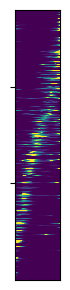

In [10]:
mi = 4
di = 2
ki = 0
th = w[mi][di][:, ki, :].mean() + 3 * w[mi][di][:, ki, :].std()
plt.figure(figsize=(0.8, 3))
plt.pcolor(w[mi][di][w_single[mi][di][:, ki, 1].argsort(), ki, :], vmax=th)
plt.yticks([200, 400])
plt.tick_params(labelleft=False, bottom=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs5/figs5d_w.png")

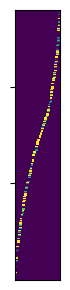

In [11]:
tmp = np.zeros_like(w[mi][di][:, ki, :])
for i, (a, p) in enumerate(w_single[mi][di][:, ki, :]):
    tmp[i, int(max(0, p-1)):int(p+2)] = a
th = w[mi][di][:, ki, :].max(axis=-1).mean() + 3 * w[mi][di][:, ki, :].max(axis=-1).std()
plt.figure(figsize=(0.8, 3))
plt.pcolor(tmp[w_single[mi][di][:, ki, 1].argsort()], vmax=th)
plt.yticks([200, 400])
plt.tick_params(labelleft=False, bottom=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs5/figs5e_w.png")

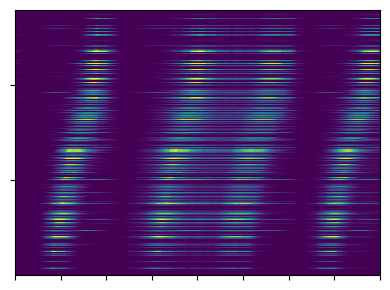

In [12]:
start = 2000
u = cp.asnumpy(igpu.conv(cp.array(w[mi][di][:, ki:ki+1, :]), cp.array(h[mi][di][:, ki:ki+1]).T, 1e-7)).T[start:start+400]
plt.figure(figsize=(4, 3))
plt.pcolor(u.T[w_single[mi][di][:, ki, 1].argsort()], vmax=u.mean()+5*u.std())
plt.yticks([200, 400])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs5/figs5d_x.png")

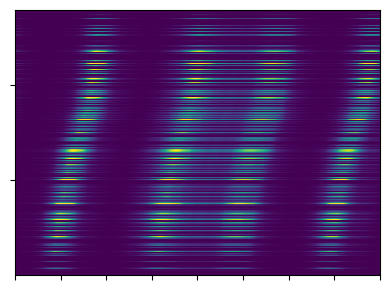

In [13]:
u = cp.asnumpy(igpu.single.conv_single(
    cp.array(w_single[mi][di][:, ki, 0][:, cp.newaxis]),
    cp.array(w_single[mi][di][:, ki, 1][:, cp.newaxis]),
    cp.array(h_single[mi][di][start:start+449, ki:ki+1]).T, 50, 1e-7)).T
plt.figure(figsize=(4, 3))
plt.pcolor(u.T[w_single[mi][di][:, ki, 1].argsort()], vmax=u.mean()+5*u.std())
plt.yticks([200, 400])
plt.tick_params(labelleft=False, labelbottom=False)
plt.tight_layout()
plt.savefig("figures/figs5/figs5e_x.png")

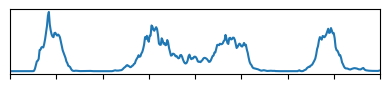

In [14]:
plt.figure(figsize=(4, 1))
plt.plot(h[mi][di][start+49:start+449, ki])
plt.tick_params(left=False, labelleft=False, labelbottom=False)
plt.xlim(0, 400)
plt.tight_layout()
plt.savefig("figures/figs5/figs5d_h.png")

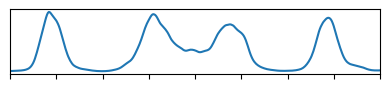

In [15]:
plt.figure(figsize=(4, 1))
plt.plot(h_single[mi][di][start+49:start+449, ki])
plt.tick_params(left=False, labelleft=False, labelbottom=False)
plt.xlim(0, 400)
plt.tight_layout()
plt.savefig("figures/figs5/figs5e_h.png")

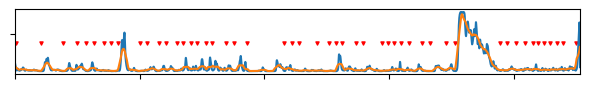

In [16]:
mi = 4
di = 2
ki = 2
move_ave = moving_average(h_single[mi][di])
plt.figure(figsize=(6, 1))
plt.plot(h_single[mi][di][49:, ki], label="Occurrence")
plt.plot(move_ave[49:, ki], label="Moving Average")
plt.scatter(np.where(beh[mi][di][:, 2] == 1), np.ones(int(beh[mi][di][:, 2].sum())) * 300, marker="v", s=5, c="r", label="Reward")
plt.yticks([400])
plt.xticks([2000 * i for i in range(5)])
plt.tick_params(labelbottom=False, labelleft=False)
plt.xlim(0, h_single[mi][di].shape[0] - 49)
plt.tight_layout()
plt.savefig("figures/figs5/figs5f.png")

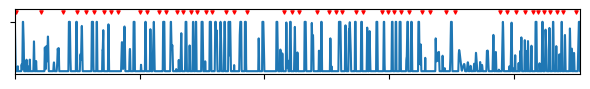

In [17]:
plt.figure(figsize=(6, 1))
plt.plot(h_spike[mi][di][49:, ki])
plt.scatter(np.where(beh[mi][di][:, 2] == 1), np.ones(int(beh[mi][di][:, 2].sum())) * 1.2, marker="v", s=5, c="r", label="Reward")
plt.yticks([1])
plt.xticks([2000 * i for i in range(5)])
plt.tick_params(labelbottom=False, labelleft=False)
plt.xlim(0, h_single[mi][di].shape[0] - 49)
plt.tight_layout()
plt.savefig("figures/figs5/figs5g.png")